**Ce code permet d'étudier l'évolution d'un parametre sur une condition donnée.**

Il permet donc de tracer l'évolution temporelle pour une condition donnée en mu, G et quantité de cellules initiale.  

Il permet aussi de tracer l'évolution de la quantité de facteur de croissance pour un mu, t et quantité de cellules initiale  donnés.   

Et finalement de tracer l'évolution de la quantité de nutriment pour un G, t et quantité de cellules initiale donnés.  


In [3]:

from pathlib import Path
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import re


def traitement_1D(matfile):


    data = scipy.io.loadmat(matfile)

    X = data["X"]
    N = data["Nsup"]

    dx = X[0,1] - X[0,0]

   
    # Projection 2D -> 1D
    # rayures // y
    
    profile = np.mean(N, axis=0)


    # Paramètres depuis le nom du fichier

    filename = Path(matfile).stem

    match = re.search(
        r"mu_([0-9.]+)_G_([0-9.]+)_t_([0-9.]+)_cell_([0-9.]+)",
        filename
    )

    if match:

        mu = float(match.group(1))
        G = float(match.group(2))
        t = float(match.group(3))
        cell = float(match.group(4))

    else:

        mu = np.nan
        G = np.nan
        t = np.nan
        cell = np.nan

    return {
    "profile": profile,
    "time": t,
    "cell" : cell,
    "mu" : mu,
    "G": G,
    "X": X[0, :],
    "dx": dx,
    }   

In [4]:
from collections import defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

dossier = "Evoltemp_1D3"
folder = Path(f"./{dossier}")

results = []

for matfile in folder.glob("*.mat"):

    print(f"Analyse : {matfile.name}")

    try:

        res = traitement_1D(matfile)

        results.append(res)


    except Exception as e:

        print(
            f"Erreur sur {matfile.name}: {e}"
        )


Analyse : mu_0.150_G_0.100_t_0_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_0_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_0_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_100000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_100000_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_100000_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_10000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_10000_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_10000_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_110000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_110000_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_110000_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_120000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_120000_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_120000_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_130000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_130000_cell_100000.mat
Analyse : mu_0.150_G_0.100_t_130000_cell_25000.mat
Analyse : mu_0.150_G_0.100_t_140000_cell_10000.mat
Analyse : mu_0.150_G_0.100_t_140000_cell_10

- # Evolution du temps :

La cellule ci dessous va réaliser une figure qui trace l'évolution des motifs au cours du temps. Elle va réaliser un graphe pour chaque condition présente dans le dossier, et enregistrer le résultat.

*Attention* : Il faut que le dossier importé ait plusieurs temps differents pour une même condition  (exemple dossier EvolTemp_1D3)

In [ ]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

groups = defaultdict(list)

for res in results:

    key = (
        res["mu"],
        res["G"],
        res["cell"]
    )

    groups[key].append(res)


for (mu, G, cell), simu in groups.items():

    # Tri chronologique
    simu = sorted(simu, key=lambda r: r["time"])

    times = np.array([r["time"] for r in simu])

    profiles = np.array([
        r["profile"]
        for r in simu
    ])

    X = simu[0]["X"]

    plt.figure(figsize=(10,6))

    TT, XX = np.meshgrid(times, X, indexing="ij")
    
    plt.pcolormesh(
            XX,
            TT,
            profiles,
            shading="auto",
            cmap="viridis",
            vmin=0,
            vmax= 800000
        )

    plt.xlabel("x")
    plt.ylabel("Temps")

    plt.title(
        f"μ={mu:.3f}, G={G:.3f}, cellules={cell:.0f}"
    )

    cbar = plt.colorbar()
    cbar.set_label("Densité cellulaire")

    plt.tight_layout()

    filename = (
        f"mu_{mu:.3f}"
        f"_G_{G:.3f}"
        f"_cell_{cell:.0f}"
        "_spacetime.png"
    )

    plt.savefig(
        folder / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

- ## Comparaison spacetime :

La cellule ci dessous va réaliser une figure qui compare l'évolution temporelle de 3 conditions choisies. 

*Attention* : Il faut que le dossier importé ait plusieurs temps differents pour les conditions souhaitées  

<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
C:\Users\lisab\AppData\Local\Temp\ipykernel_35660\1274486856.py:81: SyntaxWarning: invalid escape sequence '\m'
  rf"$\mu$={mu:.2f}" + "\n" +


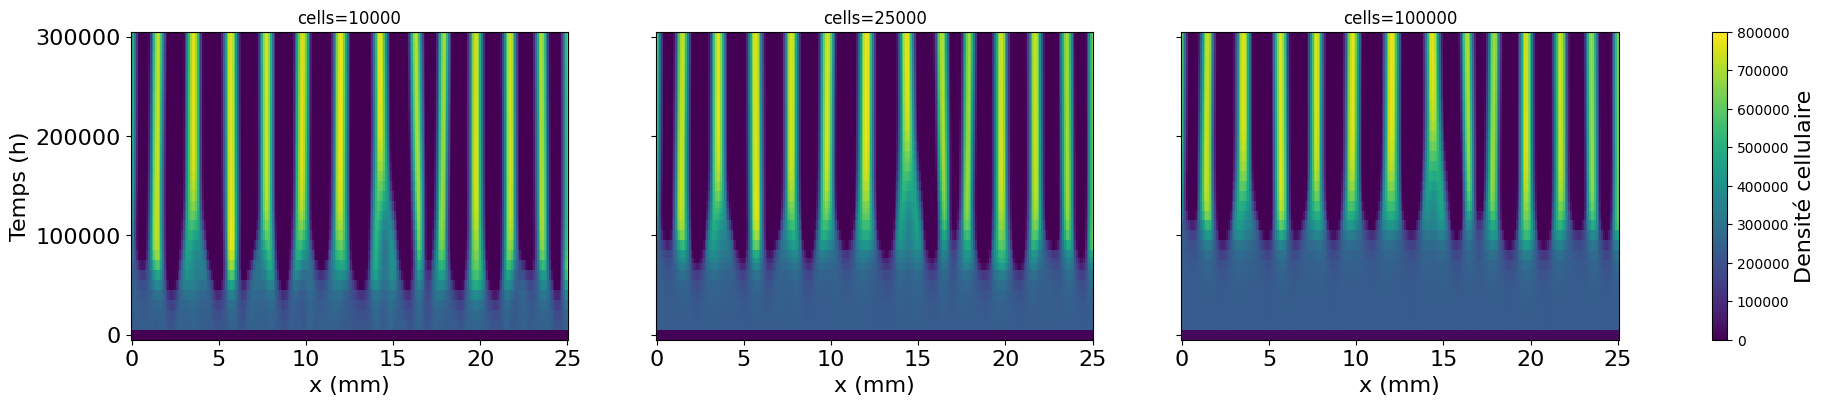

In [ ]:
from collections import defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


groups = defaultdict(list)

for res in results:
    key = (
        res["mu"],
        res["G"],
        res["cell"]
    )
    groups[key].append(res)


# Conditions à comparer ( choisir les parametres qu'on veut comparer)
conditions = [
    (0.25, 0.03, 10000),
    (0.25, 0.03, 25000),
    (0.25, 0.03, 100000)
]


fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(8*len(conditions),4),
    sharex=True,
    sharey=True
)

# Cas où une seule condition est demandée
if len(conditions) == 1:
    axes = [axes]

for ax, key in zip(axes, conditions):

    if key not in groups:
        ax.set_title("Condition absente")
        ax.axis("off")
        continue

    simu = sorted(
        groups[key],
        key=lambda r: r["time"]
    )

    times = np.array([r["time"] for r in simu])

    profiles = np.array([
        r["profile"]
        for r in simu
    ])

    X = simu[0]["X"]

    TT, XX = np.meshgrid(
        times,
        X,
        indexing="ij"
    )

    im = ax.pcolormesh(
        XX,
        TT,
        profiles,
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=800000
    )

    mu, G, cell = key

    #Les titres sont à ajuster en fonction des conditions qu'on souhaite comparer
    '''
    ax.set_title(
        rf"$\mu$={mu:.2f}" + "\n" +
        f"G={G:.2f}"
    )'''

    ax.set_title(
            f"cells={cell:.0f}" 
        )

    ax.set_xlabel("x (mm)", fontsize = 16)
    ax.tick_params(axis='both', labelsize=16)
    

axes[0].set_ylabel("Temps (h)", fontsize = 16)


# Une seule colorbar pour toute la figure
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=1, 
    
)
cbar.set_label("Densité cellulaire" , fontsize = 16)

#plt.tight_layout()

plt.savefig(
    folder / "Comparaison_spacetime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- # Evolution de la concentration en facteur de croissances :

La cellule ci dessous va réaliser une figure qui trace l'évolution des motifs lors de l'augmentation de la concentration en facteur de croissance. Elle va réaliser un graphe pour chaque condition présente dans le dossier, et enregistrer le résultat.

*Attention* : Il faut que le dossier importé ait plusieurs G differents pour une même condition de mu, t et cell.  

In [ ]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

groups = defaultdict(list)

for res in results:

    key = (
        res["mu"],
        res["time"],
        res["cell"]
    )

    groups[key].append(res)


for (mu, time, cell), simu in groups.items():

    # Tri chronologique
    simu = sorted(simu, key=lambda r: r["G"])

    Gs = np.array([r["G"] for r in simu])

    profiles = np.array([
        r["profile"]
        for r in simu
    ])

    X = simu[0]["X"]

    plt.figure(figsize=(10,6))
    MU, XX = np.meshgrid(Gs, X, indexing="ij")
    
    plt.pcolormesh(
        XX,
        MU,
        profiles,
        shading="auto",
        cmap="viridis"
    )
    
    '''plt.imshow(
        profiles,
        origin="lower",
        aspect="auto",
        extent=[
            X.min(),
            X.max(),
            Gs.min(),
            Gs.max()
        ],
        cmap="viridis"
    )'''

    plt.xlabel("x")
    plt.ylabel("G")

    plt.title(
        f"μ={mu:.3f}, Time={time:.3f}, cellules={cell:.0f}"
    )

    cbar = plt.colorbar()
    cbar.set_label("Nombre cellulaire")

    plt.tight_layout()

    filename = (
        f"mu_{mu:.3f}"
        f"_cell_{cell:.0f}"
        "_Gspace.png"
    )

    plt.savefig(
        folder / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

- # Evolution de la concentration en nutriment :

La cellule ci dessous va réaliser une figure qui trace l'évolution des motifs lors de l'augmentation de la concentration en nutriment. Elle va réaliser un graphe pour chaque condition présente dans le dossier, et enregistrer le résultat.

*Attention* : Il faut que le dossier importé ait plusieurs mu differents pour une même condition de G, t et cell.  

In [ ]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

groups = defaultdict(list)

for res in results:

    key = (
        res["G"],
        res["time"],
        res["cell"]
    )

    groups[key].append(res)


for (G, time, cell), simu in groups.items():

    # Tri chronologique
    simu = sorted(simu, key=lambda r: r["mu"])

    mus = np.array([r["mu"] for r in simu])

    profiles = np.array([
        r["profile"]
        for r in simu
    ])

    X = simu[0]["X"]

    plt.figure(figsize=(10,6))

    GG, XX = np.meshgrid(mus, X, indexing="ij")

    plt.pcolormesh(
        XX,
        GG,
        profiles,
        shading="auto",
        cmap="viridis"
    )

    plt.xlabel("x")
    plt.ylabel("mu")

    plt.title(
        f"G={G:.3f}, Time={time:.3f}, cellules={cell:.0f}"
    )

    cbar = plt.colorbar()
    cbar.set_label("Nombre cellulaire")

    plt.tight_layout()

    filename = (
        f"G_{G:.3f}"
        f"_cell_{cell:.0f}"
        "_muspace.png"
    )

    plt.savefig(
        folder / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

